# AutoML percentile correction (M4) — mean-bias direction

This notebook uses the **mean bias sign** across CV rows to set hi/lo direction.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from utilsforecast.losses import rmse

from datasetsforecast.m4 import M4, M4Info
from datasetsforecast.m3 import M3, M3Info
from mlforecast.auto import xgboost_space
import optuna

from utilsforecast.losses import rmse, mse, bias, mae

def eval_metrics(valid_df, preds_df, model_col: str):
    df = valid_df.merge(preds_df, on=["unique_id", "ds"], how="inner")
    return {
        "rows": len(df),
        "rmse": float(rmse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mse": float(mse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "bias": float(bias(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mae": float(mae(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
    }

def rmse_loss(df, train_df):  # train_df is unused here
    # df has columns: ["unique_id", "ds", "cutoff", "y", "model"]
    return rmse(df, models=["model"], id_col="unique_id", target_col="y")["model"].mean()

/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
group = "Weekly"
M4.download("data", group=group)
df, *_ = M4.load(directory="data", group=group)
df["ds"] = df["ds"].astype(int)

# Tweedie requires non-negative targets. Shift per series if needed.
min_by_id = df.groupby("unique_id")["y"].min()
#offset_by_id = (-min_by_id).clip(lower=0).rename("offset").reset_index()
#df = df.merge(offset_by_id, on="unique_id", how="left")

h = M4Info[group].horizon
season_length = M4Info[group].seasonality

n_windows = 2
num_samples = 1  # increase for stronger tuning
optimize_kwargs = {"timeout": 300}

In [3]:
import pandas as pd

def rolling_holdout_splits(df, h, n_test_sets, time_col="ds"):
    # ensure datetime
    ds = pd.to_datetime(df[time_col])
    all_ds = sorted(ds.unique())
    max_ds = all_ds[-1]

    step = pd.Timedelta(days=1) 

    for k in range(n_test_sets):
        test_end = max_ds - k * h * step
        test_start = test_end - (h - 1) * step

        train = df[df[time_col] < test_start]
        test = df[(df[time_col] >= test_start) & (df[time_col] <= test_end)]

        yield k, train.reset_index(drop=True), test.reset_index(drop=True)


In [4]:
def tweedie_space(trial):
    params = xgboost_space(trial)
    params["objective"] = "reg:tweedie"
    params["tweedie_variance_power"] = 1.5
    params["eval_metric"] = "tweedie-nloglik@1.5"
    return params


In [5]:
from sklearn.preprocessing import FunctionTransformer
from mlforecast.target_transforms import LocalStandardScaler, GlobalSklearnTransformer

from mlforecast.lag_transforms import (RollingMean, ExponentiallyWeightedMean, ExpandingMax, ExpandingMin,
                                       RollingStd)

LAGS = [
    [1],
    [1, 2, 3],
    [1, 2, 3, 7],
    [1, 7, 14],
    [1, 7, 14, 28],
]

LAG_TRANSFORMS = [
    {1: [ExponentiallyWeightedMean(0.9),
         ExpandingMax(),
         ExpandingMin(),
         RollingStd(window_size=3, min_samples=1),
         RollingStd(window_size=8, min_samples=3),
         RollingMean(window_size=3, min_samples=1),
         RollingMean(window_size=8, min_samples=3)
         ]
     },
   # {
   #     1: [ExponentiallyWeightedMean(0.9)],
   #     7: [RollingMean(window_size=3, min_samples=1)],
   # },
]

DATE_FEATURES = ["year", "month", "week", "weekday"]  # standard calendar features

def my_init_config(trial):
    lags_idx = trial.suggest_int("lags_idx", 0, len(LAGS) - 1)
    ltfm_idx = trial.suggest_int("lag_tfms_idx", 0, len(LAG_TRANSFORMS) - 1)
    return {
        "target_transforms": None,   # no differencing
        "lags": LAGS[lags_idx],
        "lag_transforms": LAG_TRANSFORMS[ltfm_idx],
        "date_features": ["weekday", "week", "month"]

    }


In [6]:
from datasetsforecast.m5 import M5

Y_df, X_df, S_df = M5.load(directory="data")

In [7]:
all_ids = Y_df.unique_id.unique().tolist()

rng = np.random.default_rng(42)
sample_ids = rng.choice(all_ids, size=200, replace=False).tolist()

df = Y_df[Y_df.unique_id.isin(sample_ids)]

df.shape

(310683, 3)

In [16]:
def my_fit_config(trial):
    return {
        "dropna": False,
    }
    
n_test_sets = 5
h = 7
n_windows = 10
num_samples = 10
step_size = 7

rmse_base_test = []
mse_base_test = []
mae_base_test = []
bias_base_test = []

rmse_corr_test = []
mse_corr_test = []
mae_corr_test = []
bias_corr_test = []

cv_rmse_normal_cv = []
cv_bias_normal_cv = []

cv_rmse_corr_cv = []
cv_bias_corr_cv = []

rmse_base_only_corrected_test = []
mse_base_only_corrected_test = []
mae_base_only_corrected_test = []
bias_base_only_corrected_test = []

rmse_corr_only_corrected_test = []
mse_corr_only_corrected_test = []
mae_corr_only_corrected_test = []
bias_corr_only_corrected_test = []

share_correction = []
p_val_cv = []

for i, train_i, test_i in rolling_holdout_splits(df, h, n_test_sets):
    from mlforecast.auto import AutoMLForecast, AutoXGBoost, PredictionIntervals
    
    #auto_base = AutoMLForecast(
    #models={"xgb": AutoXGBoost(config=tweedie_space)},
    #freq="D",
    #init_config=my_init_config,
    #fit_config=my_fit_config,
    #reuse_cv_splits=True
    #)

    auto_corr = AutoMLForecast(
        models={"xgb": AutoXGBoost(config=tweedie_space)},
        freq="D",
        init_config=my_init_config,
        fit_config=my_fit_config,
        reuse_cv_splits=True
    )
    
    print(i, train_i.ds.min(), train_i.ds.max(), " | ", 
          test_i.ds.min(), test_i.ds.max())

    length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()

    good_ids = length_ids[length_ids.ds > 100].unique_id.unique()

    train_i = train_i[train_i.unique_id.isin(good_ids)].copy()
    test_i = test_i[test_i.unique_id.isin(good_ids)].copy()
    
    # Train base model:
    #auto_base.fit(
    #df=train_i,
    #n_windows=n_windows,
    #h=h,
    #num_samples=num_samples,
    #step_size=5,
    #loss=rmse_loss,
    #study_kwargs={"sampler": optuna.samplers.TPESampler()}
    # prediction_intervals=PredictionIntervals(n_windows=n_windows, h=h),
    #)

    #preds_base = auto_base.predict(h=test_i.ds.nunique())
    #metrics_base = eval_rmse_bias(test_i, preds_base, "xgb")
    
    # Train corrected model:
    auto_corr.percentile_correction_levels_ = list(range(1, 51))
    auto_corr.fit(
    df=train_i,
    n_windows=n_windows,
    h=h,
    num_samples=num_samples,
    step_size=step_size,
    prediction_intervals=PredictionIntervals(n_windows=6, h=h),
    percentile_correction=True,
    percentile_correction_strict_bias=False,
    compute_corrected_cv_metrics=True,
    loss=rmse_loss,
    study_kwargs={"sampler": optuna.samplers.TPESampler()}
    )

    preds_corr = auto_corr.predict(h=test_i.ds.nunique())
    
    name = "xgb"
    corr = auto_corr.percentile_correction_[name]
    corr_ids = list(corr["id_to_col"].keys())
    raw_preds = auto_corr.models_[name].predict(
        h=test_i.ds.nunique(),
        level=corr["levels"],  # make sure percentile cols exist
    )
    
    metrics_corr = eval_metrics(test_i, preds_corr, "xgb")
    metrics_base = eval_metrics(test_i, raw_preds, "xgb")
    
    metrics_corr_only_corrected = eval_metrics(test_i[test_i.unique_id.isin(corr_ids)], 
                                                 preds_corr[preds_corr.unique_id.isin(corr_ids)], "xgb")
    metrics_base_only_corrected = eval_metrics(test_i[test_i.unique_id.isin(corr_ids)], 
                                                 raw_preds[raw_preds.unique_id.isin(corr_ids)], "xgb")
    
    rmse_base = metrics_base['rmse']
    mse_base = metrics_base['mse']
    mae_base = metrics_base['mae']
    bias_base = metrics_base['bias']
    
    rmse_corr = metrics_corr['rmse']
    mse_corr = metrics_corr['mse']
    mae_corr = metrics_corr['mae']
    bias_corr = metrics_corr['bias']
    
    rmse_base_only_corrected = metrics_base_only_corrected['rmse']
    mse_base_only_corrected = metrics_base_only_corrected['mse']
    mae_base_only_corrected = metrics_base_only_corrected['mae']
    bias_base_only_corrected = metrics_base_only_corrected['bias']
    
    rmse_corr = metrics_corr['rmse']
    mse_corr = metrics_corr['mse']
    mae_corr = metrics_corr['mae']
    bias_corr = metrics_corr['bias']
    
    rmse_corr_only_corrected = metrics_corr_only_corrected ['rmse']
    mse_corr_only_corrected = metrics_corr_only_corrected ['mse']
    mae_corr_only_corrected = metrics_corr_only_corrected ['mae']
    bias_corr_only_corrected = metrics_corr_only_corrected ['bias']
    
    cv_rmse_normal = auto_corr.cv_metrics_["xgb"]['rmse']
    cv_bias_normal = auto_corr.cv_metrics_["xgb"]['bias']
    
    cv_rmse_corr = auto_corr.cv_metrics_corrected_["xgb"]['rmse']
    cv_bias_corr = auto_corr.cv_metrics_corrected_["xgb"]['bias']
    
    #############
    # save outputs
    rmse_base_test.append(rmse_base)
    mse_base_test.append(mse_base)
    mae_base_test.append(mae_base)
    bias_base_test.append(bias_base)
    
    rmse_corr_test.append(rmse_corr)
    mse_corr_test.append(mse_corr)
    mae_corr_test.append(mae_corr)
    bias_corr_test.append(bias_corr)
    
    rmse_base_only_corrected_test.append(rmse_base_only_corrected)
    mse_base_only_corrected_test.append(mse_base_only_corrected)
    mae_base_only_corrected_test.append(mae_base_only_corrected)
    bias_base_only_corrected_test.append(bias_base_only_corrected)
    
    rmse_corr_only_corrected_test.append(rmse_corr_only_corrected)
    mse_corr_only_corrected_test.append(mse_corr_only_corrected)
    mae_corr_only_corrected_test.append(mae_corr_only_corrected)
    bias_corr_only_corrected_test.append(bias_corr_only_corrected)
    
    cv_rmse_normal_cv.append(cv_rmse_normal)
    cv_bias_normal_cv.append(cv_bias_normal)
    
    cv_rmse_corr_cv.append(cv_rmse_corr)
    cv_bias_corr_cv.append(cv_bias_corr)
    ###############
    # Get base and corrected forecast from correction model:
    

    # raw predictions WITH the needed percentile columns
    #raw_preds = auto_corr.models_[name].predict(
    #    h=test_i.ds.nunique(),
    #    level=corr["levels"],  # make sure percentile cols exist
    #)

    # corrected predictions (auto_corr.predict applies correction)
    preds_optimal = auto_corr.predict(h=test_i.ds.nunique())
    ###############
    preds_all = raw_preds.merge(preds_optimal, on=['ds', 'unique_id'])
    
    corr_ids_str = set(map(str, corr_ids))
    preds_all = preds_all[preds_all.unique_id.astype(str).isin(corr_ids_str)]
    
    preds_all = preds_all.merge(test_i, on=['ds', 'unique_id'])

    preds_all['res_base'] = abs(preds_all.xgb_x - preds_all.y)
    preds_all['res_best'] = abs(preds_all.xgb_y - preds_all.y)

    preds_all['flag'] = np.where(preds_all.res_best < preds_all.res_base, 1, 0)
    share_correction.append(preds_all['flag'].mean())
    #############
    # Run t-test:
    t_stat, p_val = stats.ttest_ind(preds_all.xgb_x, 
                                preds_all.xgb_y, 
                                equal_var=True)  
    p_val_cv.append(p_val)

0 2011-01-29 00:00:00 2016-06-12 00:00:00  |  2016-06-13 00:00:00 2016-06-19 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_13690/3657882534.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-02-27 12:06:19,631] A new study created in memory with name: no-name-c762b23c-4831-498c-a3b8-84892c1fac49
[I 2026-02-27 12:06:28,546] Trial 0 finished with value: 1.3914666175842285 and parameters: {'n_estimators': 533, 'max_depth': 10, 'learning_rate': 0.004317376510167734, 'subsample': 0.5760396793540714, 'colsample_bytree': 0.3291524936353382, 'reg_lambda': 7.402205825772924e-07, 'reg_alpha': 0.0006346866370915685, 'min_child_weight': 6, 'lags_idx': 0, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.3914666175842285.
[I 2026-02-27 12:06:30,323] Trial 1 finished with value: 1.306178689002990

1 2011-01-29 00:00:00 2016-06-05 00:00:00  |  2016-06-06 00:00:00 2016-06-12 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_13690/3657882534.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-02-27 12:13:34,043] A new study created in memory with name: no-name-cfd54160-8efd-43f3-8ed2-003481c9a6b0
[I 2026-02-27 12:13:34,964] Trial 0 finished with value: 1.2997994422912598 and parameters: {'n_estimators': 47, 'max_depth': 10, 'learning_rate': 0.19041295636741387, 'subsample': 0.5374401712113579, 'colsample_bytree': 0.21119769044605838, 'reg_lambda': 8.726550620314547e-05, 'reg_alpha': 0.1930104124951171, 'min_child_weight': 8, 'lags_idx': 4, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.2997994422912598.
[I 2026-02-27 12:13:40,246] Trial 1 finished with value: 1.3309471607208252 an

2 2011-01-29 00:00:00 2016-05-29 00:00:00  |  2016-05-30 00:00:00 2016-06-05 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_13690/3657882534.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-02-27 12:18:42,487] A new study created in memory with name: no-name-a1054cf3-5c3b-4e01-8046-b0a04966306c
[I 2026-02-27 12:18:44,693] Trial 0 finished with value: 1.5325011014938354 and parameters: {'n_estimators': 372, 'max_depth': 2, 'learning_rate': 0.002262427037588807, 'subsample': 0.7928599738286808, 'colsample_bytree': 0.9118544676428254, 'reg_lambda': 0.02201232176872502, 'reg_alpha': 1.0745489315640503e-07, 'min_child_weight': 4, 'lags_idx': 0, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.5325011014938354.
[I 2026-02-27 12:18:48,700] Trial 1 finished with value: 1.2436602115631104 

3 2011-01-29 00:00:00 2016-05-22 00:00:00  |  2016-05-23 00:00:00 2016-05-29 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_13690/3657882534.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-02-27 12:22:14,550] A new study created in memory with name: no-name-07f02576-c94c-4360-b90e-48f7803bebb8
[I 2026-02-27 12:22:18,163] Trial 0 finished with value: 1.2603591680526733 and parameters: {'n_estimators': 602, 'max_depth': 4, 'learning_rate': 0.006352028804026446, 'subsample': 0.8559490402666988, 'colsample_bytree': 0.6984492073319778, 'reg_lambda': 5.311978925734023e-06, 'reg_alpha': 1.36362019208291e-06, 'min_child_weight': 7, 'lags_idx': 2, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.2603591680526733.
[I 2026-02-27 12:22:23,580] Trial 1 finished with value: 1.2811161279678345 

4 2011-01-29 00:00:00 2016-05-15 00:00:00  |  2016-05-16 00:00:00 2016-05-22 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_13690/3657882534.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-02-27 12:25:34,864] A new study created in memory with name: no-name-61d35356-9e34-44ba-8146-c6d205744524
[I 2026-02-27 12:25:39,874] Trial 0 finished with value: 1.2791985273361206 and parameters: {'n_estimators': 651, 'max_depth': 7, 'learning_rate': 0.04920338628494802, 'subsample': 0.8664483195860941, 'colsample_bytree': 0.3343929082652282, 'reg_lambda': 0.0009946141603844928, 'reg_alpha': 8.144861458184066e-06, 'min_child_weight': 7, 'lags_idx': 3, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.2791985273361206.
[I 2026-02-27 12:25:45,740] Trial 1 finished with value: 1.3803104162216187 

In [17]:
metrics_corr_only_corrected

{'rows': 1400,
 'rmse': 1.147024393081665,
 'mse': 2.495206356048584,
 'bias': 0.09929455816745758,
 'mae': 0.9424113631248474}

In [18]:
metrics_base_only_corrected

{'rows': 1400,
 'rmse': 1.184058666229248,
 'mse': 2.5936098098754883,
 'bias': 0.2566063702106476,
 'mae': 1.012276291847229}

In [19]:
import numpy as np
count = np.sum(np.array(bias_corr_only_corrected_test) 
               < np.array(bias_base_only_corrected_test))
count / len(bias_base_only_corrected_test)


np.float64(0.8)

In [21]:
count = np.sum(np.array(rmse_corr_only_corrected_test) 
               < np.array(rmse_base_only_corrected_test))
count / len(rmse_base_only_corrected_test)

np.float64(0.8)

In [22]:
print(np.mean(rmse_base_only_corrected_test),
      np.mean(rmse_corr_only_corrected_test),
      
np.mean(np.abs(bias_base_only_corrected_test)),
np.mean(np.abs(bias_corr_only_corrected_test))
)

1.3303289890289307 1.3191560506820679 0.12008242905139924 0.11571007817983628


In [34]:
share_correction

[np.float64(0.5871428571428572),
 np.float64(0.6521428571428571),
 np.float64(0.6514285714285715),
 np.float64(0.6128571428571429),
 np.float64(0.6714285714285714)]

In [24]:
import numpy as np
print(
    np.mean(share_correction),
    np.std(share_correction),
    len(share_correction)
)


0.635 0.03056608765095253 5


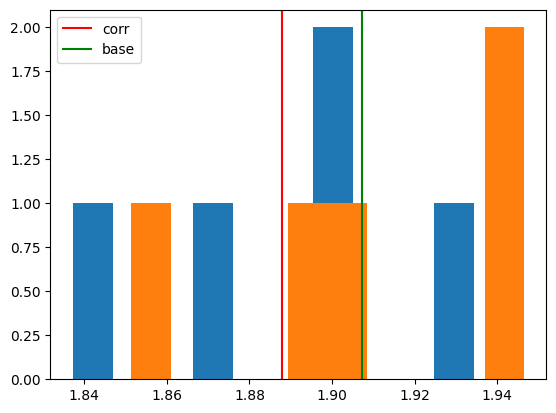

In [25]:
import matplotlib.pyplot as plt

plt.hist(cv_rmse_corr_cv)
plt.axvline(np.mean(cv_rmse_corr_cv), color='red', label='corr')
plt.hist(cv_rmse_normal_cv)
plt.axvline(np.mean(cv_rmse_normal_cv),  color='green', label='base')
plt.legend()
plt.show()

In [26]:
np.mean(rmse_corr_test) / np.mean(rmse_base_test) - 1

np.float64(-0.00839862803787994)

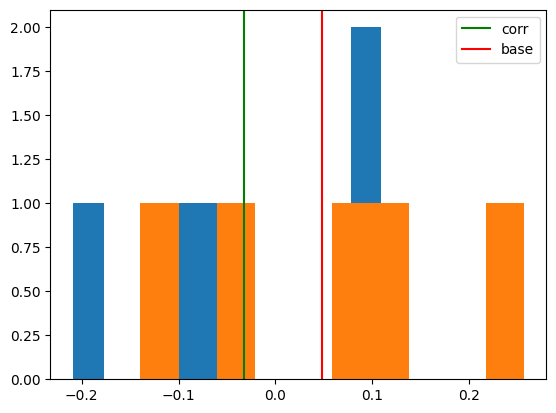

In [27]:
plt.hist(bias_corr_test)
plt.axvline(np.mean(bias_corr_test), label='corr', color='green')
plt.hist(bias_base_test)
plt.axvline(np.mean(bias_base_test), label='base', color='red')
plt.legend()
plt.show()

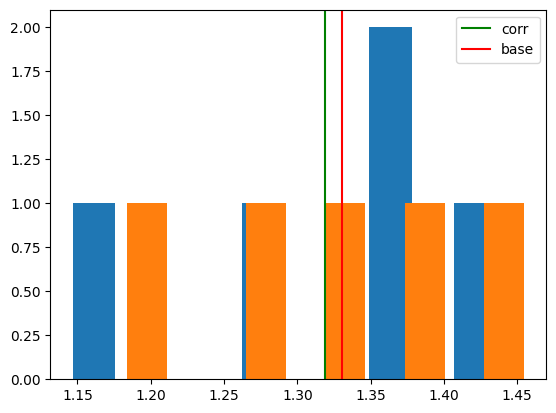

In [28]:
plt.hist(rmse_corr_test)
plt.axvline(np.mean(rmse_corr_test), label='corr', color='green')
plt.hist(rmse_base_test)
plt.axvline(np.mean(rmse_base_test), label='base', color='red')
plt.legend()
plt.show()

In [29]:
count = np.sum(np.array(mae_corr_test) 
               < np.array(mae_base_test))
count / len(bias_base_only_corrected_test)

np.float64(0.8)

In [30]:
print(np.mean(mae_corr_test),
np.mean((mae_base_test)))

1.0574921250343323 1.1003139972686768


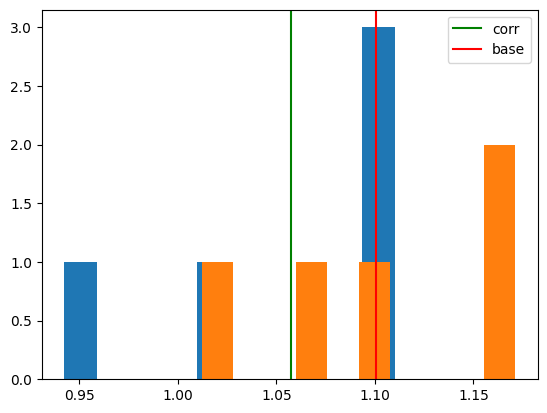

In [31]:
plt.hist(mae_corr_test)
plt.axvline(np.mean(mae_corr_test), label='corr', color='green')
plt.hist(mae_base_test)
plt.axvline(np.mean(mae_base_test), label='base', color='red')
plt.legend()
plt.show()

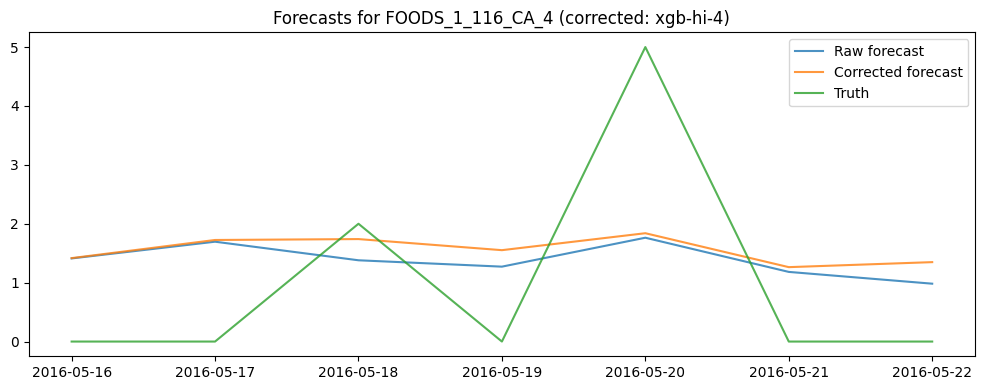

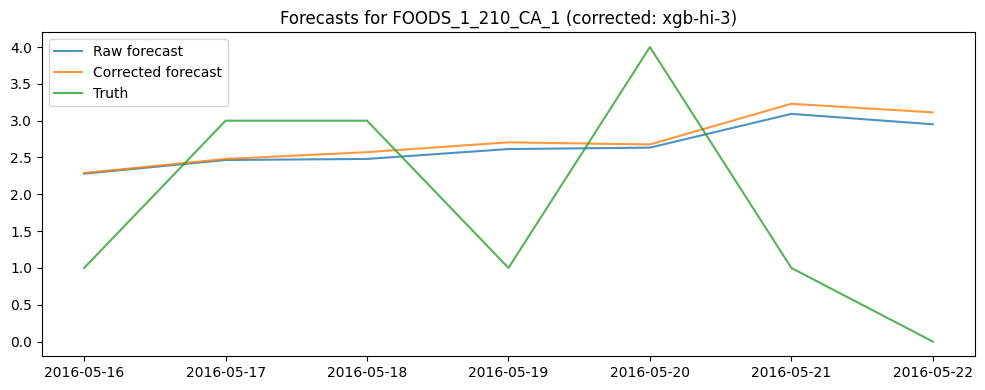

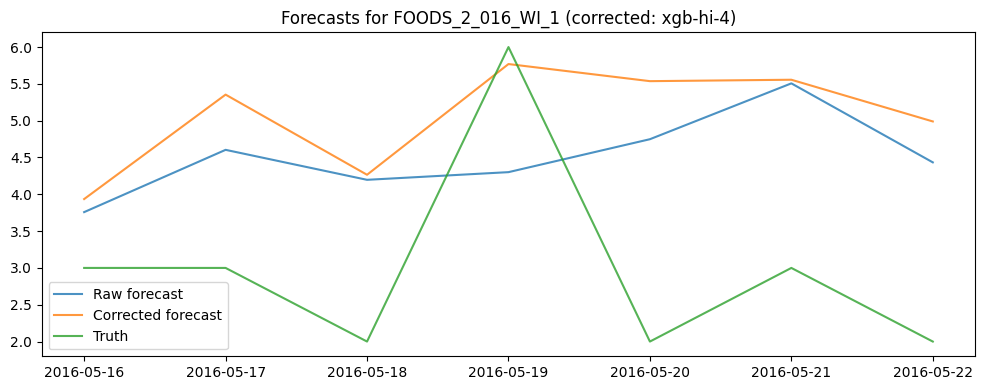

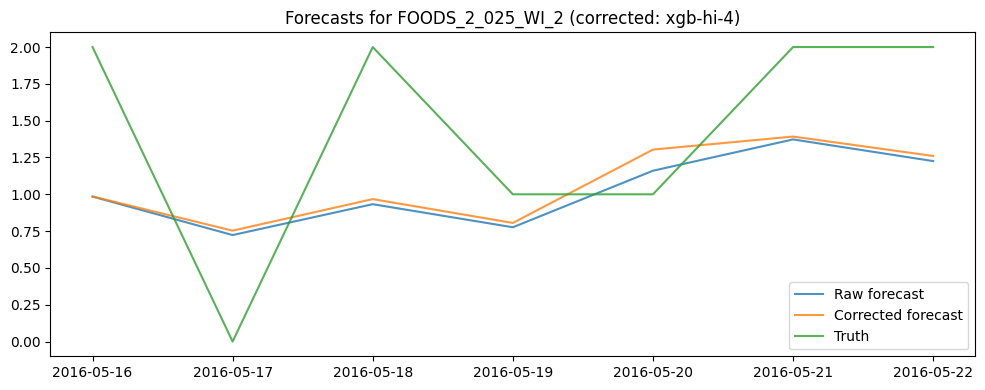

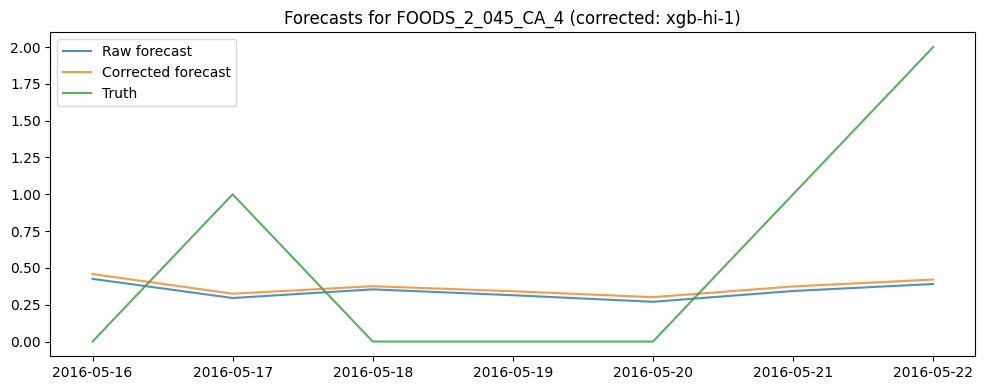

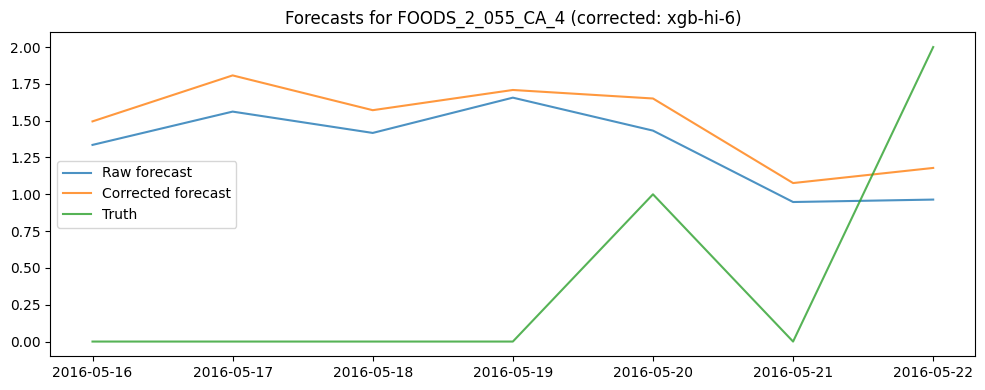

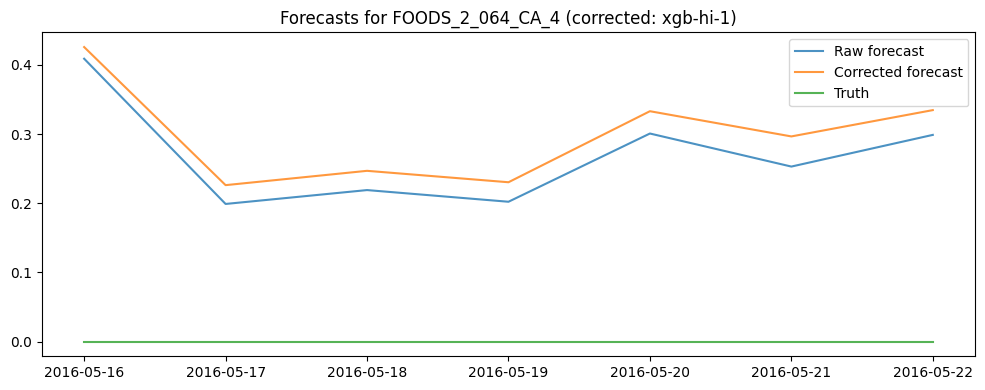

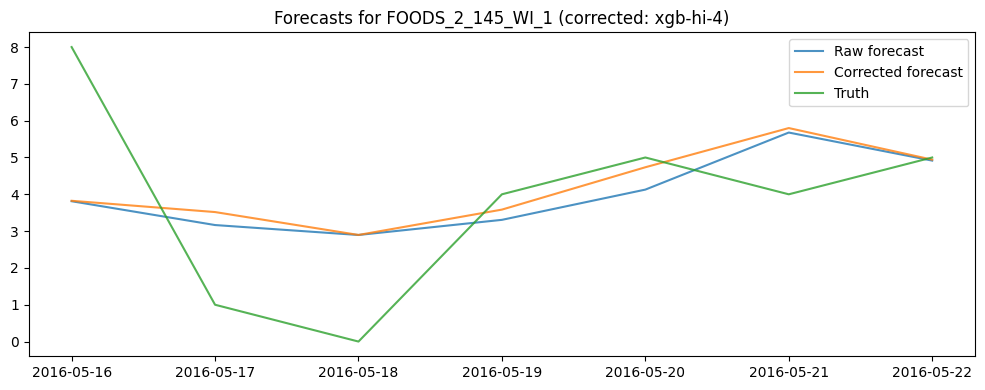

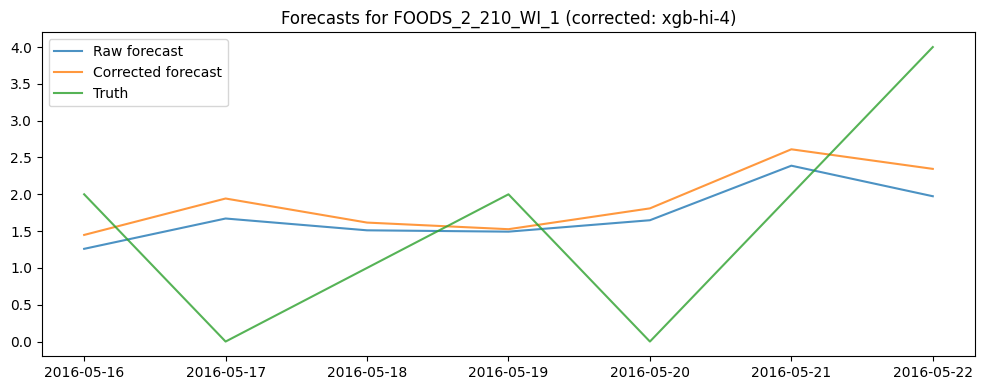

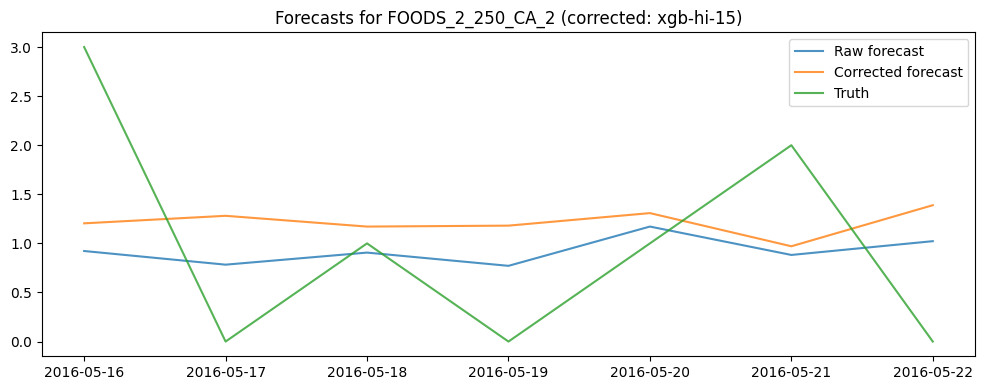

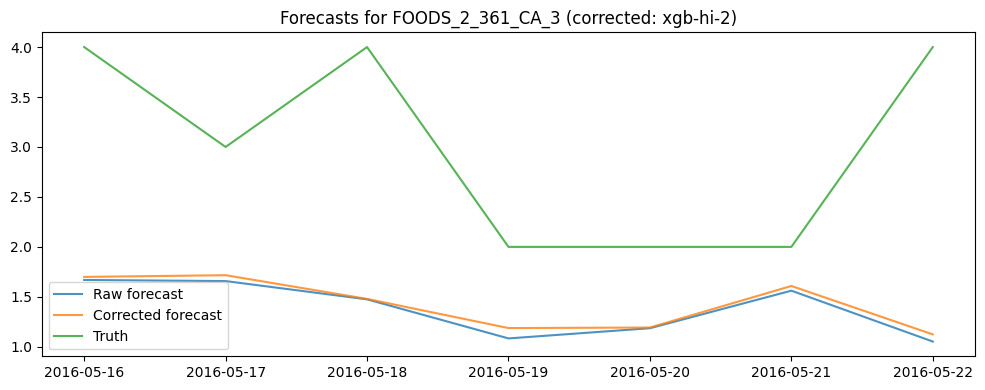

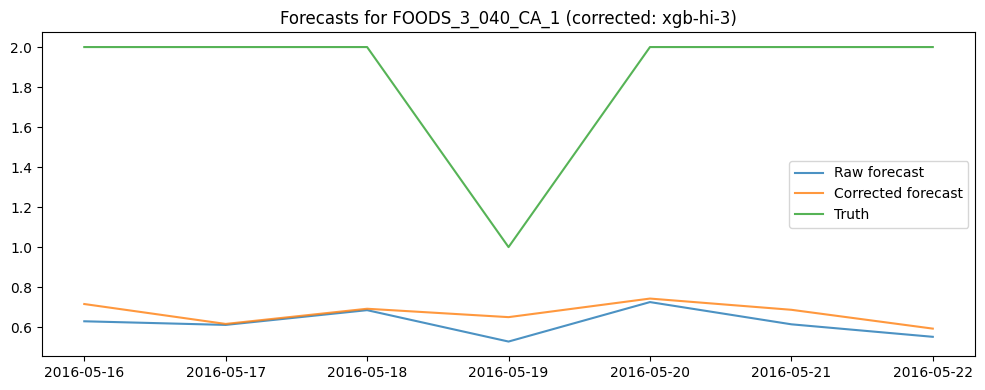

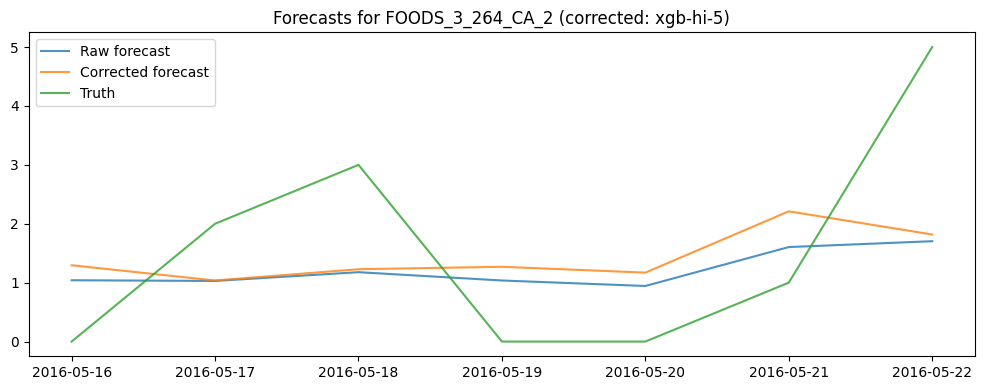

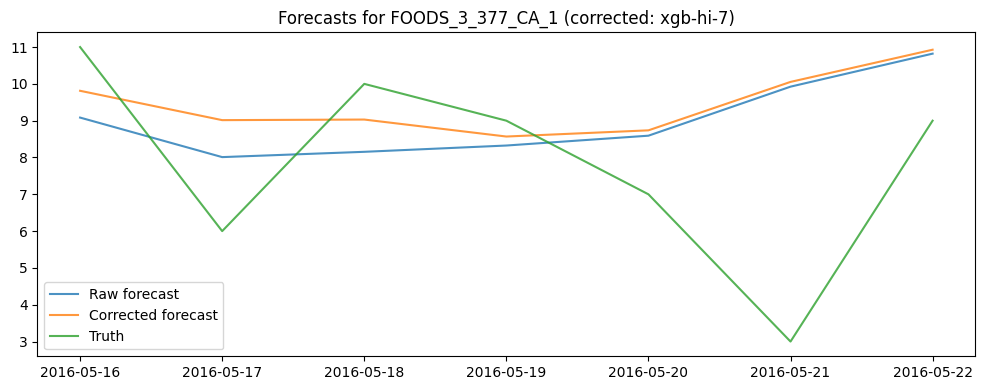

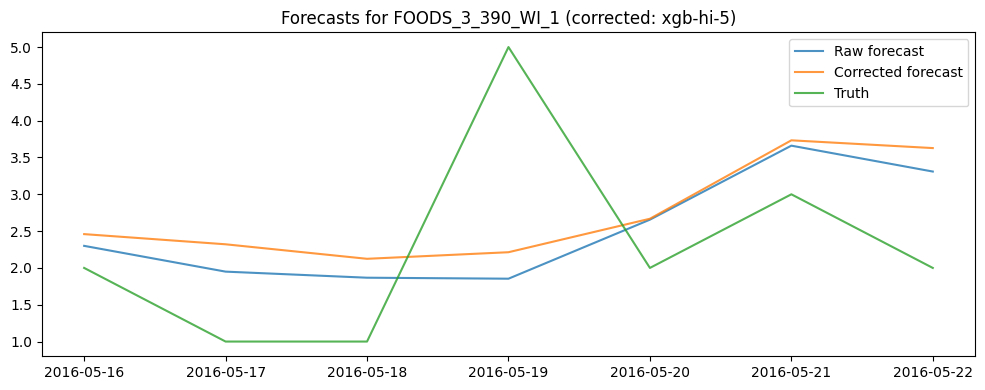

In [33]:
import matplotlib.pyplot as plt

name = "xgb"
corr = auto_corr.percentile_correction_[name]
corr_ids = list(corr["id_to_col"].keys())

# raw predictions WITH the needed percentile columns
raw_preds = auto_corr.models_[name].predict(
    h=h,
    level=corr["levels"],  # make sure percentile cols exist
)

# corrected predictions (auto_corr.predict applies correction)
corr_preds = auto_corr.predict(h=h)

for uid in corr_ids[0:15]:
    raw_uid = raw_preds[raw_preds["unique_id"] == uid]
    corr_uid = corr_preds[corr_preds["unique_id"] == uid]
    test_uid = test_i[test_i["unique_id"] == uid]
    train_uid = train_i[train_i["unique_id"] == uid]
    

    plt.figure(figsize=(10, 4))
    #plt.plot(valid_uid["ds"], valid_uid["y"], label="Actuals (valid.y)", color="black", alpha=0.8)
    plt.plot(raw_uid["ds"], raw_uid[name], label="Raw forecast", alpha=0.8)
    plt.plot(corr_uid["ds"], corr_uid[name], label="Corrected forecast", alpha=0.8)
    plt.plot(test_uid["ds"], test_uid['y'], label="Truth", alpha=0.8)
    # plt.plot(train_uid["ds"], train_uid['y'], label="Truth", alpha=0.8)
    plt.title(f"Forecasts for {uid} (corrected: {corr['id_to_col'][uid]})")
    plt.legend()
    plt.tight_layout()
    plt.show()
